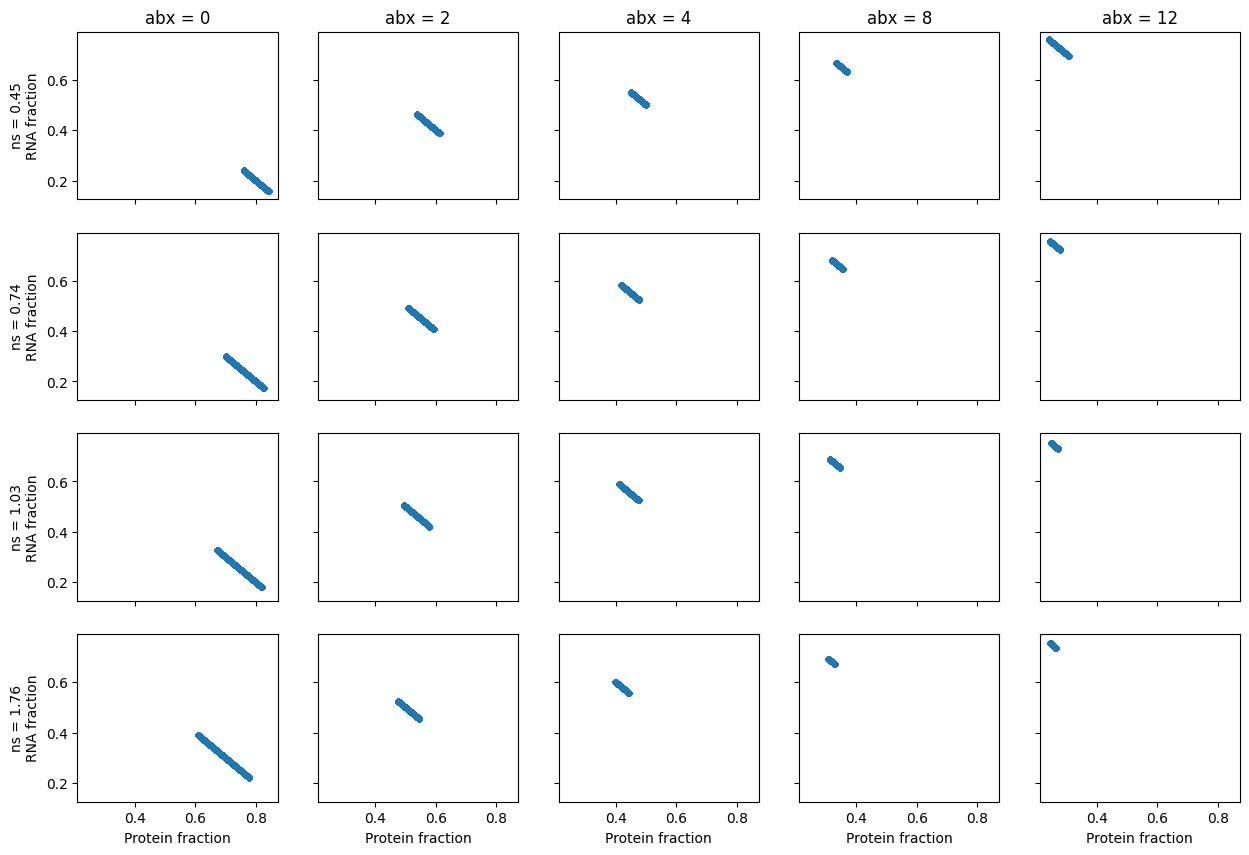

In [3]:
# ============================================================
# RNA vs Protein CONCENTRATIONS
# (mass fractions) for each ns and abx
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# ------------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------------

NS_VALUES  = [0.45, 0.74, 1.03, 1.76]
ABX_VALUES = [0, 2, 4, 8, 12]

BURN_IN = 1000.0

MW_AA = 110.0
MW_NT = 321.0
AVOGADRO = 6.022e23
NR = 7549.0
NX = 300.0
RIBO_RNA_NT = 4565
BURN_IN = 1000.0

# ------------------------------------------------------------
# LOAD FUNCTION
# ------------------------------------------------------------

def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

# ------------------------------------------------------------
# MASS FUNCTIONS
# ------------------------------------------------------------
def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo  = NX * (q + et + em)
    return ribo_mass + non_ribo

def compute_protein_mass(df):
    protein_molecules = compute_mass(df)
    return (protein_molecules / AVOGADRO) * MW_AA

def compute_RNA_nt(df):
    mm = (df["mm(t)"] + df["rmm(t)"] + df["zmm(t)"]) * (3 * NX)
    mt = (df["mt(t)"] + df["rmt(t)"] + df["zmt(t)"]) * (3 * NX)
    mq = (df["mq(t)"] + df["rmq(t)"] + df["zmq(t)"]) * (3 * NX)
    mr = (df["mr(t)"] + df["rmr(t)"] + df["zmr(t)"]) * (3 * NR)

    r_tot = (
        df["r(t)"] + df["rmm(t)"] + df["rmt(t)"] +
        df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] +
        df["zmq(t)"] + df["zmr(t)"]
    )

    return (mm + mt + mq + mr + r_tot * RIBO_RNA_NT).to_numpy()

def compute_RNA_mass(df):
    total_nt = compute_RNA_nt(df)

    return (total_nt / AVOGADRO) * MW_NT


# ------------------------------------------------------------
# GRID PLOT
# ------------------------------------------------------------

fig, axes = plt.subplots(
    len(NS_VALUES),
    len(ABX_VALUES),
    figsize=(15, 10),
    sharex=True,
    sharey=True
)

for i, ns in enumerate(NS_VALUES):
    for j, abx in enumerate(ABX_VALUES):

        if abx == 0:
            path = f"Data/ns{int(ns*100):03d}.arrow"
        else:
            path = f"Data/ns{int(ns*100):03d}/abx{abx}.arrow"

        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        protein_mass = compute_protein_mass(df)
        RNA_mass     = compute_RNA_mass(df)

        total_mass = protein_mass + RNA_mass

        protein_conc = protein_mass / total_mass
        RNA_conc     = RNA_mass / total_mass

        ax = axes[i, j]
        ax.scatter(
            protein_conc,
            RNA_conc,
            s=10,
            alpha=0.3
        )

        # # reference line: y = 1 - x
        # x_line = np.linspace(0, 1, 100)
        # ax.plot(x_line, 1 - x_line, color="black", linewidth=1)

        if i == 0:
            ax.set_title(f"abx = {abx}")

        if j == 0:
            ax.set_ylabel(f"ns = {ns}\nRNA fraction")

        if i == len(NS_VALUES) - 1:
            ax.set_xlabel("Protein fraction")


plt.show()

In [4]:
# ============================================================
# ROBUSTNESS ANALYSIS: y1, y2, r1, r2 CORRELATIONS
# ============================================================

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.ipc as ipc

# ------------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------------

NS_VALUES  = [0.45, 0.74, 1.03, 1.76]
ABX_VALUES = [0, 2, 4, 8, 12]

NR = 7549.0
NX = 300.0
RIBO_RNA_NT = 4565

AVOGADRO = 6.022e23
MW_AA = 110.0
MW_NT = 321.0

BURN_IN = 1000.0

# ------------------------------------------------------------
# LOAD FUNCTION
# ------------------------------------------------------------

def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

# ------------------------------------------------------------
# MASS FUNCTIONS
# ------------------------------------------------------------

def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo  = NX * (q + et + em)

    return ribo_mass + non_ribo  # amino acid count proxy

def compute_protein_mass(df):
    protein_aa = compute_mass(df)
    return (protein_aa / AVOGADRO) * MW_AA

def compute_RNA_nt(df):
    mm = (df["mm(t)"] + df["rmm(t)"] + df["zmm(t)"]) * (3 * NX)
    mt = (df["mt(t)"] + df["rmt(t)"] + df["zmt(t)"]) * (3 * NX)
    mq = (df["mq(t)"] + df["rmq(t)"] + df["zmq(t)"]) * (3 * NX)
    mr = (df["mr(t)"] + df["rmr(t)"] + df["zmr(t)"]) * (3 * NR)

    r_tot = (
        df["r(t)"] + df["rmm(t)"] + df["rmt(t)"] +
        df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] +
        df["zmq(t)"] + df["zmr(t)"]
    )

    return (mm + mt + mq + mr + r_tot * RIBO_RNA_NT).to_numpy()

def compute_RNA_mass(df):
    total_nt = compute_RNA_nt(df)
    return (total_nt / AVOGADRO) * MW_NT

# ------------------------------------------------------------
# r1 and r2
# ------------------------------------------------------------

def compute_r1(df):
    # total mass proxy (amino acid units)
    M = compute_mass(df)

    # transcript length (ribosomal class)
    nr = 3 * NR

    transcript_count = (
        df["mr(t)"] +
        df["rmr(t)"] +
        df["zmr(t)"]
    ).to_numpy()

    return (nr * transcript_count) / M

def compute_all_quantities(df):

    protein_mass = compute_protein_mass(df)
    rna_mass     = compute_RNA_mass(df)

    volume = protein_mass + rna_mass

    y1 = rna_mass / volume
    y2 = protein_mass / volume

    ratio = rna_mass / protein_mass  # = y1/y2

    r1 = compute_r1(df)

    r2 = r1 * y2

    return y1, y2, ratio, r1, r2

# ------------------------------------------------------------
# CORRELATION
# ------------------------------------------------------------

def corr(x, y):
    mask = (~np.isnan(x)) & (~np.isnan(y))
    if np.sum(mask) < 3:
        return np.nan
    return np.corrcoef(x[mask], y[mask])[0, 1]

# ------------------------------------------------------------
# SWEEP CONDITIONS
# ------------------------------------------------------------

records = []

for ns in NS_VALUES:
    for abx in ABX_VALUES:

        path = f"Data/ns{int(ns*100):03d}/abx{abx}.arrow"

        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        y1, y2, ratio, r1, r2 = compute_all_quantities(df)

        records.append({
            "ns": ns,
            "abx": abx,
            "corr_y1_r1": corr(y1, r1),
            "corr_y1_r2": corr(y1, r2),
            "corr_ratio_r1": corr(ratio, r1),
            "corr_ratio_r2": corr(ratio, r2),
        })

df_corr = pd.DataFrame(records)
print("\n=== Correlation Robustness Results ===\n")
print(df_corr.sort_values(["ns", "abx"]))


=== Correlation Robustness Results ===

      ns  abx  corr_y1_r1  corr_y1_r2  corr_ratio_r1  corr_ratio_r2
0   0.45    0    0.862310    0.794483       0.852165       0.776250
1   0.45    2    0.956346    0.873930       0.956744       0.873556
2   0.45    4    0.972509    0.894688       0.972741       0.894447
3   0.45    8    0.985837    0.912675       0.985780       0.911737
4   0.45   12    0.990465    0.988943       0.998018       0.995342
5   0.74    0    0.841772    0.794294       0.844868       0.796183
6   0.74    2    0.966895    0.901553       0.968006       0.902221
7   0.74    4    0.981166    0.919628       0.981266       0.918804
8   0.74    8    0.992555    0.951430       0.992618       0.950436
9   0.74   12    0.997119    0.989390       0.998176       0.988740
10  1.03    0    0.850711    0.803625       0.854599       0.806093
11  1.03    2    0.971404    0.913771       0.972619       0.914615
12  1.03    4    0.982777    0.927888       0.983388       0.927991
13  1.0


=== Model Analogue Comparison ===

      ns  abx  corr_ribo_rna  corr_ribo_ratio  corr_ribo_non_riboRNA
0   0.45    0       0.999928         0.518858               0.940121
1   0.45    2       0.999380         0.332559               0.918494
2   0.45    4       0.999275         0.249826               0.952676
3   0.45    8       0.999176         0.161181               0.970661
4   0.45   12       0.998206        -0.459697               0.998240
5   0.74    0       0.999855         0.671730               0.936782
6   0.74    2       0.999599         0.376532               0.924813
7   0.74    4       0.999555         0.259566               0.953114
8   0.74    8       0.999520         0.194757               0.967001
9   0.74   12       0.999452         0.015402               0.999348
10  1.03    0       0.999837         0.721773               0.952214
11  1.03    2       0.999677         0.428681               0.919018
12  1.03    4       0.999641         0.274821               0.95535

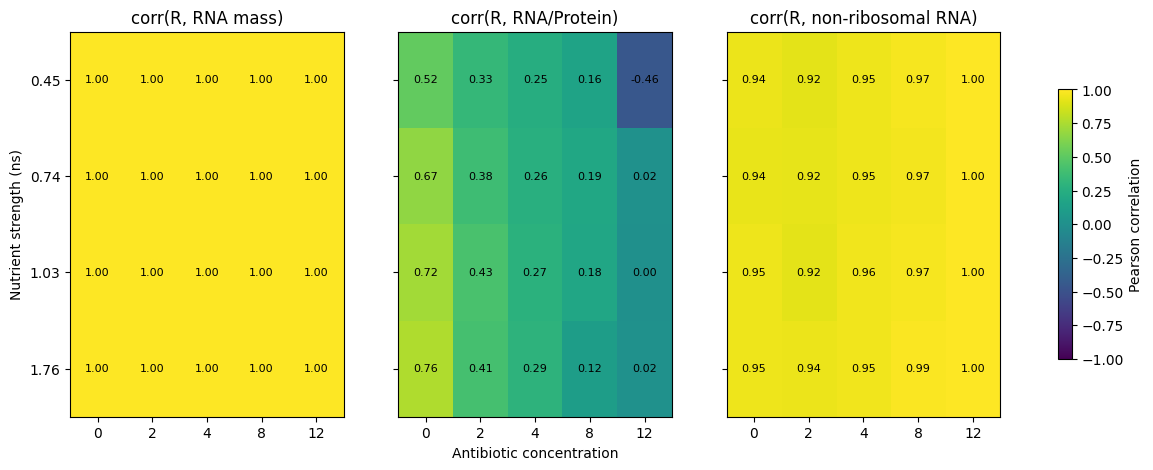

In [9]:
# ============================================================
# MODEL vs RAMAN ANALOGUE COMPARISON
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# ------------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------------

NS_VALUES  = [0.45, 0.74, 1.03, 1.76]
ABX_VALUES = [0, 2, 4, 8, 12]

NR = 7549.0
NX = 300.0
RIBO_RNA_NT = 4565

AVOGADRO = 6.022e23
MW_AA = 110.0
MW_NT = 321.0

BURN_IN = 1000.0

# ------------------------------------------------------------
# LOAD FUNCTION
# ------------------------------------------------------------

def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

# ------------------------------------------------------------
# TRUE RIBOSOME COUNT (GROUND TRUTH)
# ------------------------------------------------------------

def compute_ribosome_count(df):
    return (
        df["r(t)"] + df["rmm(t)"] + df["rmt(t)"] +
        df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] +
        df["zmq(t)"] + df["zmr(t)"]
    ).to_numpy()

# ------------------------------------------------------------
# MASS FUNCTIONS
# ------------------------------------------------------------

def compute_total_protein_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo  = NX * (q + et + em)

    total_aa = ribo_mass + non_ribo

    return (total_aa / AVOGADRO) * MW_AA


def compute_total_RNA_mass(df):

    # mRNA contributions
    mm = (df["mm(t)"] + df["rmm(t)"] + df["zmm(t)"]) * (3 * NX)
    mt = (df["mt(t)"] + df["rmt(t)"] + df["zmt(t)"]) * (3 * NX)
    mq = (df["mq(t)"] + df["rmq(t)"] + df["zmq(t)"]) * (3 * NX)
    mr = (df["mr(t)"] + df["rmr(t)"] + df["zmr(t)"]) * (3 * NR)

    # rRNA inside ribosomes
    r_tot = compute_ribosome_count(df)

    total_nt = (mm + mt + mq + mr).to_numpy() + r_tot * RIBO_RNA_NT

    return (total_nt / AVOGADRO) * MW_NT


# ------------------------------------------------------------
# NON-RIBOSOMAL RNA CONTROL (optional but important)
# ------------------------------------------------------------

def compute_non_ribosomal_RNA_mass(df):

    mm = (df["mm(t)"] + df["rmm(t)"] + df["zmm(t)"]) * (3 * NX)
    mt = (df["mt(t)"] + df["rmt(t)"] + df["zmt(t)"]) * (3 * NX)
    mq = (df["mq(t)"] + df["rmq(t)"] + df["zmq(t)"]) * (3 * NX)
    mr = (df["mr(t)"] + df["rmr(t)"] + df["zmr(t)"]) * (3 * NR)

    total_nt = (mm + mt + mq).to_numpy()

    return (total_nt / AVOGADRO) * MW_NT


# ------------------------------------------------------------
# CORRELATION
# ------------------------------------------------------------

def corr(x, y):
    mask = (~np.isnan(x)) & (~np.isnan(y))
    if np.sum(mask) < 3:
        return np.nan
    return np.corrcoef(x[mask], y[mask])[0,1]


# ------------------------------------------------------------
# SWEEP CONDITIONS
# ------------------------------------------------------------

records = []

for ns in NS_VALUES:
    for abx in ABX_VALUES:

        path = f"Data/ns{int(ns*100):03d}/abx{abx}.arrow"

        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        ribo = compute_ribosome_count(df)
        rna_mass = compute_total_RNA_mass(df)
        protein_mass = compute_total_protein_mass(df)
        ratio = rna_mass / protein_mass

        non_ribo_rna = compute_non_ribosomal_RNA_mass(df)

        records.append({
            "ns": ns,
            "abx": abx,
            "corr_ribo_rna": corr(ribo, rna_mass),
            "corr_ribo_ratio": corr(ribo, ratio),
            "corr_ribo_non_riboRNA": corr(ribo, non_ribo_rna)
        })

df_compare = pd.DataFrame(records)

print("\n=== Model Analogue Comparison ===\n")
print(df_compare.sort_values(["ns","abx"]))


# ------------------------------------------------------------
# HEATMAP VISUALISATION
# ------------------------------------------------------------

def make_matrix(df, column):
    mat = np.zeros((len(NS_VALUES), len(ABX_VALUES)))
    for i, ns in enumerate(NS_VALUES):
        for j, abx in enumerate(ABX_VALUES):
            value = df[(df.ns==ns)&(df.abx==abx)][column].values[0]
            mat[i,j] = value
    return mat


m_rna   = make_matrix(df_compare, "corr_ribo_rna")
m_ratio = make_matrix(df_compare, "corr_ribo_ratio")
m_non   = make_matrix(df_compare, "corr_ribo_non_riboRNA")

fig, axes = plt.subplots(1,3, figsize=(15,5), sharey=True)

titles = [
    "corr(R, RNA mass)",
    "corr(R, RNA/Protein)",
    "corr(R, non-ribosomal RNA)"
]

for ax, mat, title in zip(axes, [m_rna, m_ratio, m_non], titles):

    im = ax.imshow(mat, aspect="auto", vmin=-1, vmax=1)
    ax.set_title(title)

    ax.set_xticks(range(len(ABX_VALUES)))
    ax.set_xticklabels(ABX_VALUES)

    ax.set_yticks(range(len(NS_VALUES)))
    ax.set_yticklabels(NS_VALUES)

    for i in range(len(NS_VALUES)):
        for j in range(len(ABX_VALUES)):
            ax.text(j, i, f"{mat[i,j]:.2f}",
                    ha="center", va="center", fontsize=8)

axes[0].set_ylabel("Nutrient strength (ns)")
axes[1].set_xlabel("Antibiotic concentration")

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.7)
cbar.set_label("Pearson correlation")

plt.show()

In [12]:
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.ipc as ipc

# ============================================================
# PARAMETERS
# ============================================================

NS_VALUES  = [0.45, 0.74, 1.03, 1.76]
ABX_VALUES = [0, 2, 4, 8, 12]
BURN_IN = 1000.0

AVOGADRO = 6.022e23
MW_AA = 110.0       # g/mol
MW_NT = 330.0       # g/mol

NR = 7549.0
NX = 300.0
RIBO_RNA_NT = 4565

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def pearson_corr(x, y):
    if len(x) < 3:
        return np.nan
    return np.corrcoef(x, y)[0, 1]

# ============================================================
# MASS FUNCTIONS (MODEL)
# ============================================================

def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo  = NX * (q + et + em)

    return ribo_mass + non_ribo

def compute_protein_mass(df):
    protein_molecules = compute_mass(df)
    return (protein_molecules / AVOGADRO) * MW_AA

def compute_RNA_nt(df):
    mm = (df["mm(t)"] + df["rmm(t)"] + df["zmm(t)"]) * (3 * NX)
    mt = (df["mt(t)"] + df["rmt(t)"] + df["zmt(t)"]) * (3 * NX)
    mq = (df["mq(t)"] + df["rmq(t)"] + df["zmq(t)"]) * (3 * NX)
    mr = (df["mr(t)"] + df["rmr(t)"] + df["zmr(t)"]) * (3 * NR)

    r_tot = (
        df["r(t)"] + df["rmm(t)"] + df["rmt(t)"] +
        df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] +
        df["zmq(t)"] + df["zmr(t)"]
    )

    return (mm + mt + mq + mr + r_tot * RIBO_RNA_NT).to_numpy()

def compute_RNA_mass(df):
    total_nt = compute_RNA_nt(df)
    return (total_nt / AVOGADRO) * MW_NT

# ============================================================
# ============================================================
# PART 1 — RAMAN DATA
# ============================================================
# ============================================================

# Load Raman data
rna_df = pd.read_csv("Data/RamanData/rna.csv")
protein_df = pd.read_csv("Data/RamanData/protein.csv")
growth_df = pd.read_csv("Data/RamanData/Raman_growth.csv")

nutrients = growth_df["Condition"].unique()

raman_results = []

for nutrient in nutrients:
    for cm in ABX_VALUES:

        col = f"Cm{cm}_{nutrient}"

        if col not in rna_df.columns:
            continue

        RNA  = rna_df[col].dropna().values
        PROT = protein_df[col].dropna().values

        N = min(len(RNA), len(PROT))
        RNA = RNA[:N]
        PROT = PROT[:N]

        ratio = RNA / PROT

        # Get growth rate for this condition
        mu_row = growth_df[
            (growth_df["Condition"] == nutrient) &
            (growth_df["Dose"] == cm)
        ]

        if len(mu_row) == 0:
            continue

        mu = mu_row["Value"].values[0]

        # Since growth is per condition (not per cell),
        # we correlate mean RNA and mean ratio with growth
        raman_results.append({
            "Condition": nutrient,
            "Dose": cm,
            "mu": mu,
            "RNA_mean": np.mean(RNA),
            "ratio_mean": np.mean(ratio)
        })

df_raman_summary = pd.DataFrame(raman_results)

# Compute correlations across all conditions
corr_raman_mu_rna   = pearson_corr(df_raman_summary["mu"],
                                    df_raman_summary["RNA_mean"])

corr_raman_mu_ratio = pearson_corr(df_raman_summary["mu"],
                                    df_raman_summary["ratio_mean"])

print("\n=== RAMAN Correlations ===")
print("corr(mu, RNA)        =", corr_raman_mu_rna)
print("corr(mu, RNA/Protein)=", corr_raman_mu_ratio)

# ============================================================
# ============================================================
# PART 2 — MODEL DATA
# ============================================================
# ============================================================

model_records = []

for ns in NS_VALUES:
    for abx in ABX_VALUES:

        path = f"Data/ns{int(ns*100):03d}/abx{abx}.arrow"

        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        protein_mass = compute_protein_mass(df)
        rna_mass     = compute_RNA_mass(df)

        ratio = rna_mass / protein_mass

        # Growth rate from model = slope of log mass
        total_mass = compute_mass(df)
        timestamps = df["timestamp"].to_numpy()

        # Estimate growth rate via linear fit of log mass
        log_mass = np.log(total_mass)
        coef = np.polyfit(timestamps, log_mass, 1)
        mu_model = coef[0]

        model_records.append({
            "ns": ns,
            "abx": abx,
            "mu": mu_model,
            "RNA_mean": np.mean(rna_mass),
            "ratio_mean": np.mean(ratio)
        })

df_model_summary = pd.DataFrame(model_records)

corr_model_mu_rna   = pearson_corr(df_model_summary["mu"],
                                    df_model_summary["RNA_mean"])

corr_model_mu_ratio = pearson_corr(df_model_summary["mu"],
                                    df_model_summary["ratio_mean"])

print("\n=== MODEL Correlations ===")
print("corr(mu, RNA_mass)        =", corr_model_mu_rna)
print("corr(mu, RNA/Protein)     =", corr_model_mu_ratio)


=== RAMAN Correlations ===
corr(mu, RNA)        = 0.7126206466483948
corr(mu, RNA/Protein)= -0.38630229726899906

=== MODEL Correlations ===
corr(mu, RNA_mass)        = -0.04264043492578917
corr(mu, RNA/Protein)     = -0.1245850258579293


In [27]:
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.ipc as ipc

def pearson_corr(x, y):
    if len(x) < 3:
        return np.nan
    return np.corrcoef(x, y)[0,1]

# ------------------------------------------------------------
# RAMAN DATA
# ------------------------------------------------------------

rna_df = pd.read_csv("Data/RamanData/rna.csv")
protein_df = pd.read_csv("Data/RamanData/protein.csv")
growth_df = pd.read_csv("Data/RamanData/Raman_growth.csv")

nutrients = growth_df["Condition"].unique()
ABX_VALUES = sorted(growth_df["Dose"].unique())

raman_summary = []

for nutrient in nutrients:
    for cm in ABX_VALUES:

        col = f"Cm{cm}_{nutrient}"
        if col not in rna_df.columns:
            continue

        RNA  = rna_df[col].dropna().values
        PROT = protein_df[col].dropna().values

        N = min(len(RNA), len(PROT))
        RNA = RNA[:N]
        PROT = PROT[:N]

        ratio = RNA / PROT

        mu_row = growth_df[
            (growth_df["Condition"] == nutrient) &
            (growth_df["Dose"] == cm)
        ]

        if len(mu_row) == 0:
            continue

        mu = mu_row["Value"].values[0]

        raman_summary.append({
            "Dose": cm,
            "Condition": nutrient,
            "mu": mu,
            "RNA_mean": np.mean(RNA),
            "ratio_mean": np.mean(ratio)
        })

df_raman = pd.DataFrame(raman_summary)

# Compute correlations within each antibiotic
raman_abx_corr = []

for cm in ABX_VALUES:
    subset = df_raman[df_raman["Dose"] == cm]

    raman_abx_corr.append({
        "Dose": cm,
        "corr_mu_RNA": pearson_corr(subset["mu"], subset["RNA_mean"]),
        "corr_mu_ratio": pearson_corr(subset["mu"], subset["ratio_mean"])
    })

df_raman_abx = pd.DataFrame(raman_abx_corr)

print("\n=== RAMAN: Correlations Across Nutrients (Within Antibiotic) ===\n")
print(df_raman_abx)



=== RAMAN: Correlations Across Nutrients (Within Antibiotic) ===

   Dose  corr_mu_RNA  corr_mu_ratio
0     0     0.973132       0.990407
1     2     0.981019       0.525764
2     4     0.986322      -0.770787
3     8     0.795825      -0.858306
4    12     0.923964      -0.882637


In [57]:
# ------------------------------------------------------------
# Correlations across antibiotic (within nutrient)
# ------------------------------------------------------------

raman_abx_within_nutrient = []

for nutrient in nutrients:
    subset = df_raman[df_raman["Condition"] == nutrient]

    raman_abx_within_nutrient.append({
        "Condition": nutrient,
        "corr_mu_RNA": pearson_corr(subset["mu"], subset["RNA_mean"]),
        "corr_mu_ratio": pearson_corr(subset["mu"], subset["ratio_mean"])
    })

df_raman_abx_within_nutrient = pd.DataFrame(raman_abx_within_nutrient)

print("\n=== RAMAN: Correlations Across Antibiotic (Within Nutrient) ===\n")
print(df_raman_abx_within_nutrient)


=== RAMAN: Correlations Across Antibiotic (Within Nutrient) ===

  Condition  corr_mu_RNA  corr_mu_ratio
0       glu    -0.402214      -0.912623
1   caa_glu    -0.341790      -0.875696
2       gly    -0.613757      -0.908542
3   caa_gly     0.163986      -0.914190


In [ ]:
# ------------------------------------------------------------
# MODEL PARAMETERS
# ------------------------------------------------------------

NS_VALUES  = [0.45, 0.74, 1.03, 1.76]
BURN_IN = 1000.0

NR = 7549.0
NX = 300.0
RIBO_RNA_NT = 4565

GMAX = 12600.0
KGAMMA = 7 * 22000

AVOGADRO = 6.022e23
MW_AA = 110.0
MW_NT = 330.0

def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_mass_components(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo  = NX * (q + et + em)
    total_mass = ribo_mass + non_ribo

    return ribo_mass, total_mass

def compute_ttrate(df, total_mass):
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / ((KGAMMA * total_mass / 1e8) + a)

    active = (
        df["rmr(t)"].to_numpy() +
        df["rmt(t)"].to_numpy() +
        df["rmm(t)"].to_numpy() +
        df["rmq(t)"].to_numpy()
    )

    return active * gamma

def compute_RNA_mass(df):
    mm = (df["mm(t)"] + df["rmm(t)"] + df["zmm(t)"]) * (3 * NX)
    mt = (df["mt(t)"] + df["rmt(t)"] + df["zmt(t)"]) * (3 * NX)
    mq = (df["mq(t)"] + df["rmq(t)"] + df["zmq(t)"]) * (3 * NX)
    mr = (df["mr(t)"] + df["rmr(t)"] + df["zmr(t)"]) * (3 * NR)

    r_tot = (
        df["r(t)"] + df["rmm(t)"] + df["rmt(t)"] +
        df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] +
        df["zmq(t)"] + df["zmr(t)"]
    )

    total_nt = (mm + mt + mq + mr).to_numpy() + r_tot.to_numpy() * RIBO_RNA_NT

    return (total_nt / AVOGADRO) * MW_NT

def compute_protein_mass(df):
    ribo_mass, total_mass = compute_mass_components(df)
    return (total_mass / AVOGADRO) * MW_AA


# ------------------------------------------------------------
# BUILD MODEL SUMMARY (FIXED GROWTH)
# ------------------------------------------------------------

model_summary = []

for ns in NS_VALUES:
    for abx in ABX_VALUES:

        if abx == 0:
            path = f"Data/ns{int(ns*100):03d}.arrow"
        else:
            path = f"Data/ns{int(ns*100):03d}/abx{abx}.arrow"

        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        ribo_mass, total_mass = compute_mass_components(df)
        ttrate = compute_ttrate(df, total_mass)

        lam = (ttrate / total_mass) * 60.0  # 1/hour
        mu_model = np.mean(lam)

        RNA_mass = compute_RNA_mass(df)
        PROT_mass = compute_protein_mass(df)
        ratio = RNA_mass / PROT_mass

        model_summary.append({
            "ns": ns,
            "abx": abx,
            "mu": mu_model,
            "RNA_mean": np.mean(RNA_mass),
            "ratio_mean": np.mean(ratio)
        })

df_model = pd.DataFrame(model_summary)

# ------------------------------------------------------------
# CORRELATIONS
# ------------------------------------------------------------

model_abx_corr = []

for abx in ABX_VALUES:
    subset = df_model[df_model["abx"] == abx]

    model_abx_corr.append({
        "abx": abx,
        "corr_mu_RNA": pearson_corr(subset["mu"], subset["RNA_mean"]),
        "corr_mu_ratio": pearson_corr(subset["mu"], subset["ratio_mean"])
    })

df_model_abx = pd.DataFrame(model_abx_corr)

print("\n=== MODEL (FIXED): Correlations Across Nutrients (Within Antibiotic) ===\n")
print(df_model_abx)


=== MODEL (FIXED): Correlations Across Nutrients (Within Antibiotic) ===

   abx  corr_mu_RNA  corr_mu_ratio
0    0     0.990003       0.999185
1    2     0.999999       0.996504
2    4     0.999817       0.995977
3    8     0.999655       0.997729
4   12     0.957838      -0.953909


In [40]:
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.ipc as ipc

def pearson_corr(x, y):
    if len(x) < 3:
        return np.nan
    return np.corrcoef(x, y)[0,1]

# ------------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------------

NS_VALUES  = [0.45, 0.74, 1.03, 1.76]
ABX_VALUES = [0, 2, 4, 8, 12]
BURN_IN = 1000.0

NR = 7549.0
NX = 300.0
GMAX = 12600.0
KGAMMA = 7 * 22000

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_mass_components(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_total = (r + rmm + rmt + rmq + rmr +
                  zmm + zmt + zmq + zmr)

    ribo_mass = NR * ribo_total
    non_ribo  = NX * (q + et + em)
    total_mass = ribo_mass + non_ribo

    return ribo_total, total_mass

def compute_active_ribosomes(df):
    return (
        (df["rmm(t)"].to_numpy() +
        df["rmt(t)"].to_numpy() +
        df["rmq(t)"].to_numpy() +
        df["rmr(t)"].to_numpy())
    )

def compute_growth_rate(df, total_mass):
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / ((KGAMMA * total_mass / 1e8) + a)

    active = compute_active_ribosomes(df)

    lam = (active * gamma / total_mass) * 60.0  # 1/hour
    return lam

# ------------------------------------------------------------
# BUILD MODEL SUMMARY
# ------------------------------------------------------------

records = []

for ns in NS_VALUES:
    for abx in ABX_VALUES:

        if abx == 0:
            path = f"Data/ns{int(ns*100):03d}.arrow"
        else:
            path = f"Data/ns{int(ns*100):03d}/abx{abx}.arrow"

        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        ribo_total, total_mass = compute_mass_components(df)
        active_ribo = compute_active_ribosomes(df)

        lam = compute_growth_rate(df, total_mass)

        records.append({
            "ns": ns,
            "abx": abx,
            "mu_mean": np.mean(lam),
            "active_ribo_mean": np.mean(active_ribo),
            "active_fraction_mean": np.mean(active_ribo / ribo_total)
        })

df_model = pd.DataFrame(records)

# ------------------------------------------------------------
# CORRELATIONS ACROSS NUTRIENTS (WITHIN ANTIBIOTIC)
# ------------------------------------------------------------

corr_results = []

for abx in ABX_VALUES:
    subset = df_model[df_model["abx"] == abx]

    corr_results.append({
        "abx": abx,
        "corr_growth_active_count": pearson_corr(subset["mu_mean"],
                                             subset["active_ribo_mean"]),
        "corr_growth_active_fraction": pearson_corr(subset["mu_mean"],
                                                subset["active_fraction_mean"])
    })

df_corr = pd.DataFrame(corr_results)

print("\n=== MODEL: Active Ribosome Correlations ===\n")
print(df_corr)


=== MODEL: Active Ribosome Correlations ===

   abx  corr_growth_active_count  corr_growth_active_fraction
0    0                  0.989712                    -0.979171
1    2                  0.998562                     0.999996
2    4                  0.999133                     0.999924
3    8                  0.999716                     0.999885
4   12                  0.999684                     0.999963


In [41]:
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.ipc as ipc

def pearson_corr(x, y):
    if len(x) < 3:
        return np.nan
    return np.corrcoef(x, y)[0,1]

# ------------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------------

NS_VALUES  = [0.45, 0.74, 1.03, 1.76]
ABX_VALUES = [0, 2, 4, 8, 12]
BURN_IN = 1000.0

NR = 7549.0
NX = 300.0
GMAX = 12600.0
KGAMMA = 7 * 22000

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_mass_components(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_total = (r + rmm + rmt + rmq + rmr +
                  zmm + zmt + zmq + zmr)

    ribo_mass = NR * ribo_total
    non_ribo  = NX * (q + et + em)
    total_mass = ribo_mass + non_ribo

    return ribo_mass, total_mass

def compute_growth_rate(df, total_mass):
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / ((KGAMMA * total_mass / 1e8) + a)

    active = (
        df["rmr(t)"].to_numpy() +
        df["rmt(t)"].to_numpy() +
        df["rmm(t)"].to_numpy() +
        df["rmq(t)"].to_numpy()
    )

    lam = (active * gamma / total_mass) * 60.0
    return lam

# ------------------------------------------------------------
# BUILD SUMMARY
# ------------------------------------------------------------

records = []

for ns in NS_VALUES:
    for abx in ABX_VALUES:

        if abx == 0:
            path = f"Data/ns{int(ns*100):03d}.arrow"
        else:
            path = f"Data/ns{int(ns*100):03d}/abx{abx}.arrow"

        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        ribo_mass, total_mass = compute_mass_components(df)

        rmf = ribo_mass / total_mass

        lam = compute_growth_rate(df, total_mass)

        records.append({
            "ns": ns,
            "abx": abx,
            "mu_mean": np.mean(lam),
            "rmf_mean": np.mean(rmf)
        })

df_model = pd.DataFrame(records)

# ------------------------------------------------------------
# CORRELATIONS WITHIN ANTIBIOTIC
# ------------------------------------------------------------

corr_results = []

for abx in ABX_VALUES:
    subset = df_model[df_model["abx"] == abx]

    corr_results.append({
        "abx": abx,
        "corr_mu_rmf": pearson_corr(
            subset["mu_mean"],
            subset["rmf_mean"]
        )
    })

df_corr = pd.DataFrame(corr_results)

print("\n=== MODEL: Correlation of Growth and Ribosomal Mass Fraction ===\n")
print(df_corr)


=== MODEL: Correlation of Growth and Ribosomal Mass Fraction ===

   abx  corr_mu_rmf
0    0     0.999392
1    2     0.995457
2    4     0.995154
3    8     0.996746
4   12    -0.858676


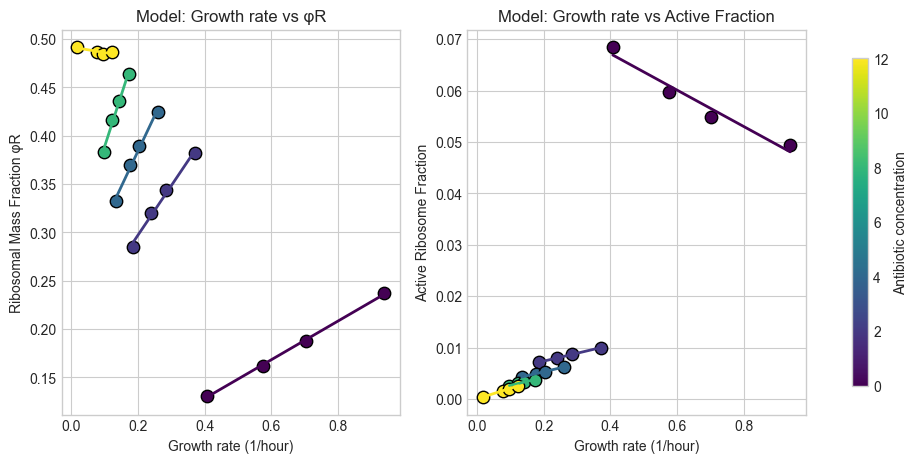

In [56]:
# ============================================================
# MODEL: Growth vs Ribosome Allocation (FIXED)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pyarrow as pa
import pyarrow.ipc as ipc

plt.style.use("seaborn-v0_8-whitegrid")

# ------------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------------

NS_VALUES  = [0.45, 0.74, 1.03, 1.76]
ABX_VALUES = [0, 2, 4, 8, 12]

NR = 7549.0
NX = 300.0
GMAX = 12600.0
KGAMMA = 7 * 22000
BURN_IN = 1000.0

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_mass_components(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_total = (r + rmm + rmt + rmq + rmr +
                  zmm + zmt + zmq + zmr)

    ribo_mass = NR * ribo_total
    non_ribo  = NX * (q + et + em)
    total_mass = ribo_mass + non_ribo

    return ribo_total, ribo_mass, total_mass

def compute_growth(df, total_mass):
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / ((KGAMMA * total_mass / 1e8) + a)

    active = (
        df["rmr(t)"].to_numpy() +
        df["rmt(t)"].to_numpy() +
        df["rmm(t)"].to_numpy() +
        df["rmq(t)"].to_numpy()
    )

    lam = (active * gamma / total_mass) * 60.0
    return lam, active

# ------------------------------------------------------------
# BUILD SUMMARY DATAFRAME
# ------------------------------------------------------------

records = []

for ns in NS_VALUES:
    for abx in ABX_VALUES:

        if abx == 0:
            path = f"Data/ns{int(ns*100):03d}.arrow"
        else:
            path = f"Data/ns{int(ns*100):03d}/abx{abx}.arrow"

        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        ribo_total, ribo_mass, total_mass = compute_mass_components(df)
        lam, active = compute_growth(df, total_mass)

        # Correct definitions
        rmf = ribo_mass / total_mass
        active_fraction = active / ribo_total

        valid = (~np.isnan(lam)) & (~np.isnan(rmf))
        lam = lam[valid]
        rmf = rmf[valid]
        active_fraction = active_fraction[valid]

        records.append({
            "ns": ns,
            "abx": abx,
            "mu_mean": np.mean(lam),
            "rmf_mean": np.mean(rmf),
            "active_fraction_mean": np.mean(active_fraction)
        })

df_model = pd.DataFrame(records)

# ------------------------------------------------------------
# PLOTTING
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12,5), sharex=True)

norm = mcolors.Normalize(
    vmin=df_model["abx"].min(),
    vmax=df_model["abx"].max()
)
cmap = cm.viridis

# μ vs φR
for abx in sorted(df_model["abx"].unique()):
    subset = df_model[df_model["abx"] == abx]
    x = subset["mu_mean"].values
    y = subset["rmf_mean"].values

    axes[0].scatter(x, y,
                    color=cmap(norm(abx)),
                    edgecolor='black',
                    s=80)

    if len(x) > 1:
        slope, intercept = np.polyfit(x, y, 1)
        x_line = np.linspace(min(x), max(x), 100)
        axes[0].plot(x_line,
                     slope*x_line + intercept,
                     color=cmap(norm(abx)),
                     linewidth=2)

axes[0].set_xlabel("Growth rate (1/hour)")
axes[0].set_ylabel("Ribosomal Mass Fraction φR")
axes[0].set_title("Model: Growth rate vs φR")

# μ vs Active Fraction
for abx in sorted(df_model["abx"].unique()):
    subset = df_model[df_model["abx"] == abx]
    x = subset["mu_mean"].values
    y = subset["active_fraction_mean"].values

    axes[1].scatter(x, y,
                    color=cmap(norm(abx)),
                    edgecolor='black',
                    s=80)

    if len(x) > 1:
        slope, intercept = np.polyfit(x, y, 1)
        x_line = np.linspace(min(x), max(x), 100)
        axes[1].plot(x_line,
                     slope*x_line + intercept,
                     color=cmap(norm(abx)),
                     linewidth=2)

axes[1].set_xlabel("Growth rate (1/hour)")
axes[1].set_ylabel("Active Ribosome Fraction")
axes[1].set_title("Model: Growth rate vs Active Fraction")

cbar = fig.colorbar(
    cm.ScalarMappable(norm=norm, cmap=cmap),
    ax=axes,
    shrink=0.85
)
cbar.set_label("Antibiotic concentration")

plt.show()

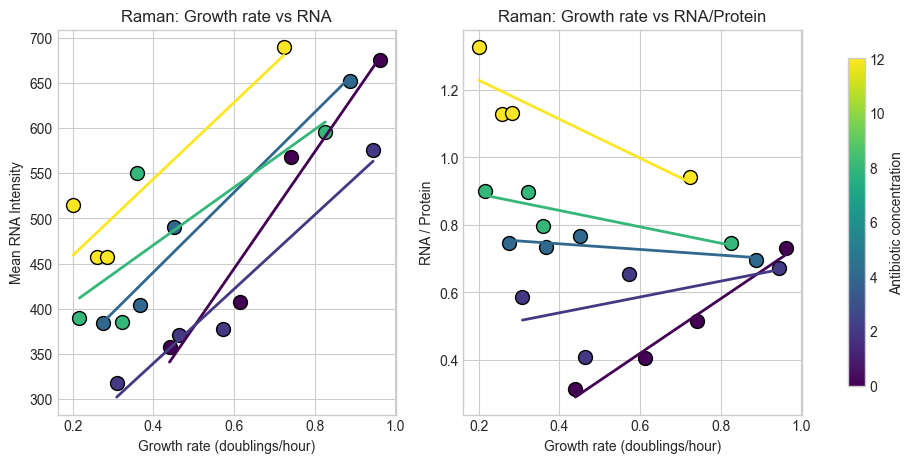

In [55]:
# ============================================================
# RAMAN: Growth vs RNA Metrics
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

plt.style.use("seaborn-v0_8-whitegrid")

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------

rna_df = pd.read_csv("Data/RamanData/rna.csv")
protein_df = pd.read_csv("Data/RamanData/protein.csv")
growth_df = pd.read_csv("Data/RamanData/Raman_growth.csv")

nutrients = growth_df["Condition"].unique()
ABX_VALUES = sorted(growth_df["Dose"].unique())

# ------------------------------------------------------------
# BUILD SUMMARY
# ------------------------------------------------------------

records = []

for nutrient in nutrients:
    for dose in ABX_VALUES:

        col = f"Cm{dose}_{nutrient}"
        if col not in rna_df.columns:
            continue

        RNA  = rna_df[col].dropna().values
        PROT = protein_df[col].dropna().values

        N = min(len(RNA), len(PROT))
        RNA = RNA[:N]
        PROT = PROT[:N]

        ratio = RNA / PROT

        mu = growth_df[
            (growth_df["Condition"] == nutrient) &
            (growth_df["Dose"] == dose)
        ]["Value"].values[0]

        records.append({
            "Condition": nutrient,
            "Dose": dose,
            "mu": mu,
            "RNA_mean": np.mean(RNA),
            "ratio_mean": np.mean(ratio)
        })

df_raman = pd.DataFrame(records)

# ------------------------------------------------------------
# PLOTTING
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12,5), sharex=True)

norm = mcolors.Normalize(
    vmin=df_raman["Dose"].min(),
    vmax=df_raman["Dose"].max()
)
cmap = cm.viridis

# μ vs RNA
for dose in sorted(df_raman["Dose"].unique()):
    subset = df_raman[df_raman["Dose"] == dose]
    x = subset["mu"].values
    y = subset["RNA_mean"].values

    axes[0].scatter(x, y,
                    color=cmap(norm(dose)),
                    edgecolor='black',
                    s=100)

    if len(x) > 1:
        slope, intercept = np.polyfit(x, y, 1)
        x_line = np.linspace(min(x), max(x), 100)
        axes[0].plot(x_line,
                     slope*x_line + intercept,
                     color=cmap(norm(dose)),
                     linewidth=2)

axes[0].set_xlabel("Growth rate (doublings/hour)")
axes[0].set_ylabel("Mean RNA Intensity")
axes[0].set_title("Raman: Growth rate vs RNA")

# μ vs RNA/Protein
for dose in sorted(df_raman["Dose"].unique()):
    subset = df_raman[df_raman["Dose"] == dose]
    x = subset["mu"].values
    y = subset["ratio_mean"].values

    axes[1].scatter(x, y,
                    color=cmap(norm(dose)),
                    edgecolor='black',
                    s=100)

    if len(x) > 1:
        slope, intercept = np.polyfit(x, y, 1)
        x_line = np.linspace(min(x), max(x), 100)
        axes[1].plot(x_line,
                     slope*x_line + intercept,
                     color=cmap(norm(dose)),
                     linewidth=2)

axes[1].set_xlabel("Growth rate (doublings/hour)")
axes[1].set_ylabel("RNA / Protein")
axes[1].set_title("Raman: Growth rate vs RNA/Protein")

cbar = fig.colorbar(
    cm.ScalarMappable(norm=norm, cmap=cmap),
    ax=axes,
    shrink=0.85
)
cbar.set_label("Antibiotic concentration")

plt.show()

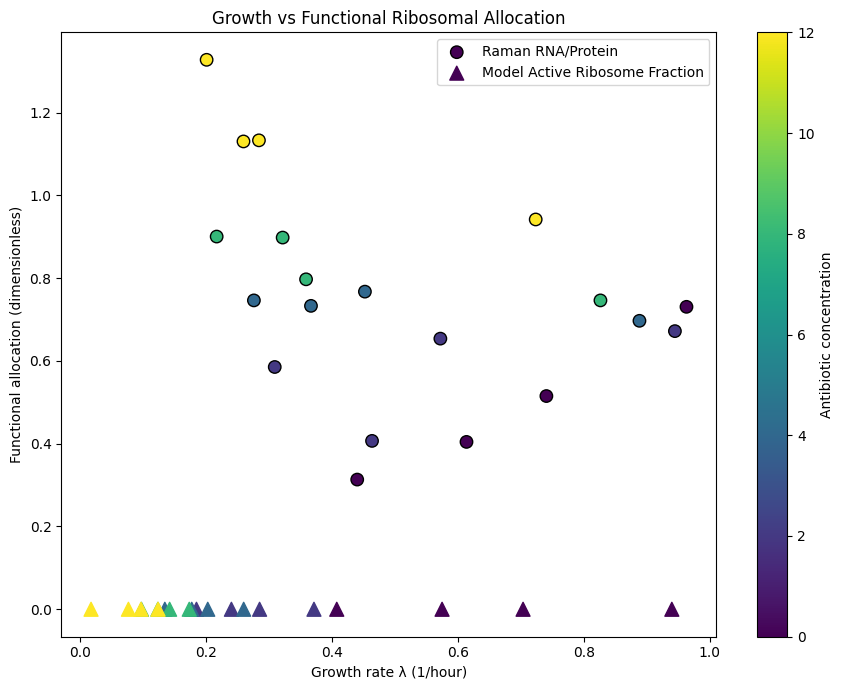

In [25]:
# ============================================================
# FINAL DEFENSIBLE COMPARISON
# Growth vs Functional Allocation
# Raman RNA/Protein vs Model Active Ribosome Fraction
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# ------------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------------

NS_VALUES  = [0.45, 0.74, 1.03, 1.76]
ABX_VALUES = [0, 2, 4, 8, 12]

NR = 7549.0
NX = 300.0
GMAX = 12600.0
KGAMMA = 7 * 22000
BURN_IN = 1000.0

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR*(r+rmm+rmt+rmq+rmr+zmm+zmt+zmq+zmr)
    non_ribo  = NX*(q+et+em)
    total     = ribo_mass + non_ribo
    return ribo_mass, total

def compute_ttrate(df, mass):
    a = df["a(t)"].to_numpy()
    gamma = GMAX * a / ((KGAMMA * mass / 1e8) + a)

    active = (
        df["rmr(t)"].to_numpy() +
        df["rmt(t)"].to_numpy() +
        df["rmm(t)"].to_numpy() +
        df["rmq(t)"].to_numpy()
    )

    return active * gamma

# ------------------------------------------------------------
# LOAD RAMAN DATA
# ------------------------------------------------------------

ratio_df = pd.read_csv("Data/RamanData/rna_protein.csv")
growth_df = pd.read_csv("Data/RamanData/Raman_growth.csv")

nutrients = growth_df["Condition"].unique()

raman_mu = []
raman_ratio = []
raman_abx = []

for nutrient in nutrients:
    for abx in ABX_VALUES:

        col = f"Cm{abx}_{nutrient}"
        if col not in ratio_df.columns:
            continue

        ratio_vals = ratio_df[col].dropna().values

        mu = growth_df[
            (growth_df["Condition"] == nutrient) &
            (growth_df["Dose"] == abx)
        ]["Value"].values[0]

        raman_mu.append(mu)
        raman_ratio.append(np.mean(ratio_vals))
        raman_abx.append(abx)

# ------------------------------------------------------------
# LOAD MODEL DATA
# ------------------------------------------------------------

model_mu = []
model_phi_active = []
model_abx = []

for ns in NS_VALUES:
    for abx in ABX_VALUES:

        if abx == 0:
            path = f"Data/ns{int(ns*100):03d}.arrow"
        else:
            path = f"Data/ns{int(ns*100):03d}/abx{abx}.arrow"

        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        ribo_mass, total_mass = compute_mass(df)
        ttrate = compute_ttrate(df, total_mass)

        lam = (ttrate / total_mass) * 60.0

        active_ribo = (
            df["rmr(t)"].to_numpy() +
            df["rmt(t)"].to_numpy() +
            df["rmm(t)"].to_numpy() +
            df["rmq(t)"].to_numpy()
        )

        phi_active = active_ribo / total_mass

        valid = (~np.isnan(lam)) & (~np.isnan(phi_active))

        model_mu.append(np.mean(lam[valid]))
        model_phi_active.append(np.mean(phi_active[valid]))
        model_abx.append(abx)

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

plt.figure(figsize=(9,7))

norm = mcolors.Normalize(vmin=0, vmax=12)
cmap = cm.viridis

# Raman
plt.scatter(raman_mu, raman_ratio,
            c=raman_abx, cmap=cmap, norm=norm,
            marker="o", s=80, edgecolor='black',
            label="Raman RNA/Protein")

# Model
plt.scatter(model_mu, model_phi_active,
            c=model_abx, cmap=cmap, norm=norm,
            marker="^", s=100,
            label="Model Active Ribosome Fraction")

plt.xlabel("Growth rate λ (1/hour)")
plt.ylabel("Functional allocation (dimensionless)")
plt.title("Growth vs Functional Ribosomal Allocation")

cbar = plt.colorbar()
cbar.set_label("Antibiotic concentration")

plt.legend()
plt.tight_layout()
plt.show()

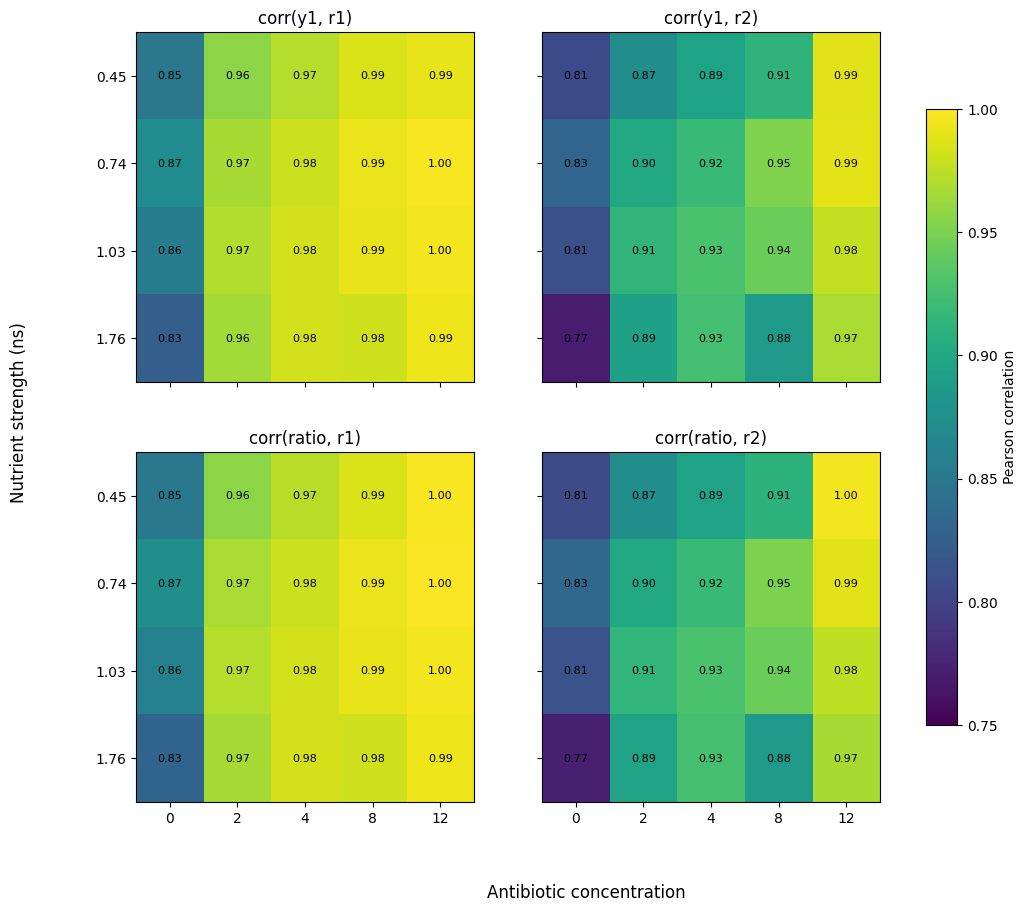

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Your correlation results (paste directly)
# ------------------------------------------------------------

data = [
[0.45,0,0.849202,0.806133,0.850274,0.806756],
[0.45,2,0.956346,0.873930,0.956744,0.873556],
[0.45,4,0.972509,0.894688,0.972741,0.894447],
[0.45,8,0.985837,0.912675,0.985780,0.911737],
[0.45,12,0.990465,0.988943,0.998018,0.995342],
[0.74,0,0.871395,0.831810,0.874695,0.834020],
[0.74,2,0.966895,0.901553,0.968006,0.902221],
[0.74,4,0.981166,0.919628,0.981266,0.918804],
[0.74,8,0.992555,0.951430,0.992618,0.950436],
[0.74,12,0.997119,0.989390,0.998176,0.988740],
[1.03,0,0.856172,0.811253,0.860062,0.813817],
[1.03,2,0.971404,0.913771,0.972619,0.914615],
[1.03,4,0.982777,0.927888,0.983388,0.927991],
[1.03,8,0.991218,0.944135,0.991524,0.943991],
[1.03,12,0.995513,0.976676,0.995784,0.975740],
[1.76,0,0.825560,0.769046,0.830808,0.772387],
[1.76,2,0.964908,0.892781,0.966125,0.893702],
[1.76,4,0.983283,0.925411,0.984071,0.926131],
[1.76,8,0.981457,0.884127,0.981903,0.884859],
[1.76,12,0.993593,0.967898,0.993515,0.967049],
]

columns = [
    "ns","abx",
    "corr_y1_r1","corr_y1_r2",
    "corr_ratio_r1","corr_ratio_r2"
]

df = pd.DataFrame(data, columns=columns)

NS_VALUES  = sorted(df["ns"].unique())
ABX_VALUES = sorted(df["abx"].unique())

# ------------------------------------------------------------
# Helper to create matrix
# ------------------------------------------------------------

def make_matrix(col):
    mat = np.zeros((len(NS_VALUES), len(ABX_VALUES)))
    for i, ns in enumerate(NS_VALUES):
        for j, abx in enumerate(ABX_VALUES):
            value = df[(df.ns==ns)&(df.abx==abx)][col].values[0]
            mat[i,j] = value
    return mat

m1 = make_matrix("corr_y1_r1")
m2 = make_matrix("corr_y1_r2")
m3 = make_matrix("corr_ratio_r1")
m4 = make_matrix("corr_ratio_r2")

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, axes = plt.subplots(2,2, figsize=(12,10), sharex=True, sharey=True)

heatmaps = [m1, m2, m3, m4]
titles = [
    "corr(y1, r1)",
    "corr(y1, r2)",
    "corr(ratio, r1)",
    "corr(ratio, r2)"
]

vmin = 0.75
vmax = 1.0

for ax, mat, title in zip(axes.flat, heatmaps, titles):

    im = ax.imshow(mat, aspect="auto", vmin=vmin, vmax=vmax)

    ax.set_title(title, fontsize=12)

    ax.set_xticks(range(len(ABX_VALUES)))
    ax.set_xticklabels(ABX_VALUES)

    ax.set_yticks(range(len(NS_VALUES)))
    ax.set_yticklabels(NS_VALUES)

    # annotate values
    for i in range(len(NS_VALUES)):
        for j in range(len(ABX_VALUES)):
            ax.text(j, i, f"{mat[i,j]:.2f}",
                    ha="center", va="center", fontsize=8)

fig.supxlabel("Antibiotic concentration")
fig.supylabel("Nutrient strength (ns)")

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
cbar.set_label("Pearson correlation")

plt.show()

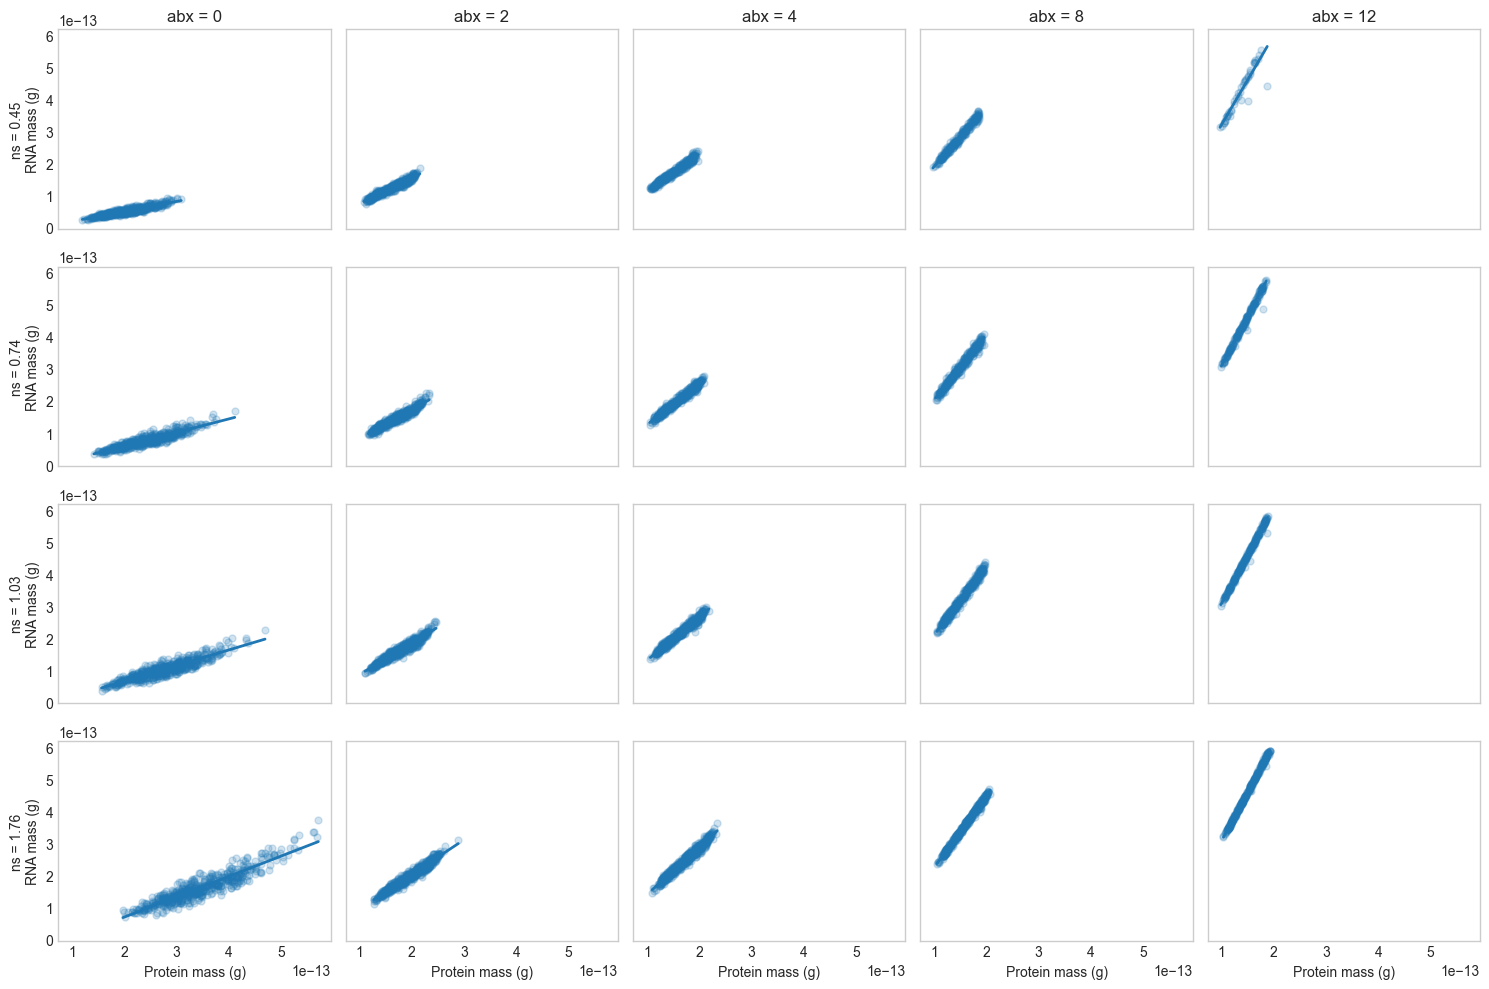

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# ============================================================
# PARAMETERS
# ============================================================

NS_VALUES  = [0.45, 0.74, 1.03, 1.76]
ABX_VALUES = [0, 2, 4, 8, 12]

NR = 7549.0
NX = 300.0
RIBO_RNA_NT = 4565
BURN_IN = 1000.0
SAMPLING_MODE = "random"

AVOGADRO = 6.022e23
MW_AA = 110.0   # g/mol
MW_NT = 330.0   # g/mol

# ============================================================
# LOAD
# ============================================================

def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

# ============================================================
# MASS CALCULATIONS
# ============================================================

def compute_total_aa(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_aa = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo_aa = NX * (q + et + em)

    return ribo_aa + non_ribo_aa


def compute_protein_mass(df):
    total_aa = compute_total_aa(df)
    return (total_aa / AVOGADRO) * MW_AA


def compute_RNA_nt(df):
    mm = (df["mm(t)"] + df["rmm(t)"] + df["zmm(t)"]) * (3 * NX)
    mt = (df["mt(t)"] + df["rmt(t)"] + df["zmt(t)"]) * (3 * NX)
    mq = (df["mq(t)"] + df["rmq(t)"] + df["zmq(t)"]) * (3 * NX)
    mr = (df["mr(t)"] + df["rmr(t)"] + df["zmr(t)"]) * (3 * NR)

    r_tot = (
        df["r(t)"] + df["rmm(t)"] + df["rmt(t)"] +
        df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] +
        df["zmq(t)"] + df["zmr(t)"]
    )

    return (mm + mt + mq + mr + r_tot * RIBO_RNA_NT).to_numpy()


def compute_RNA_mass(df):
    total_nt = compute_RNA_nt(df)
    return (total_nt / AVOGADRO) * MW_NT


# ============================================================
# DIVISION DETECTION
# ============================================================

def detect_divisions_from_mass(total_mass):
    dx = np.diff(total_mass)
    slope = np.sign(dx)
    dslope = np.diff(slope)
    max_indices = np.where(dslope == -2)[0] + 1
    return max_indices


def sample_one_per_cycle(total_mass, guard_frac=0.1):
    rng = np.random.default_rng(0)
    div_idx = detect_divisions_from_mass(total_mass)
    div_idx = np.concatenate(([0], div_idx, [len(total_mass)-1]))

    sample_indices = []

    for i in range(len(div_idx)-1):
        start = div_idx[i]
        end   = div_idx[i+1]
        L = end - start

        if L < 10:
            continue

        g = int(guard_frac * L)
        lo = start + g
        hi = end - g

        if hi > lo:
            sample_indices.append(rng.integers(lo, hi))

    return np.array(sample_indices)


# ============================================================
# PLOT GRID
# ============================================================

fig, axes = plt.subplots(len(NS_VALUES), len(ABX_VALUES),
                         figsize=(15, 10),
                         sharex=True, sharey=True)

for i, ns in enumerate(NS_VALUES):
    for j, abx in enumerate(ABX_VALUES):

        if abx == 0:
            path = f"Data/ns{int(ns*100):03d}.arrow"
        else:
            path = f"Data/ns{int(ns*100):03d}/abx{abx}.arrow"

        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        protein_mass = compute_protein_mass(df)
        rna_mass = compute_RNA_mass(df)

        idx = sample_one_per_cycle(protein_mass)

        protein_mass = protein_mass[idx]
        rna_mass = rna_mass[idx]

        ax = axes[i, j]

        ax.scatter(protein_mass, rna_mass,
                   s=25, alpha=0.2)

        if len(protein_mass) > 2:
            coef = np.polyfit(protein_mass, rna_mass, 1)
            x_grid = np.linspace(protein_mass.min(),
                                 protein_mass.max(), 100)
            y_pred = np.polyval(coef, x_grid)
            ax.plot(x_grid, y_pred, linewidth=2)

        if i == 0:
            ax.set_title(f"abx = {abx}")

        if j == 0:
            ax.set_ylabel(f"ns = {ns}\nRNA mass (g)")

        if i == len(NS_VALUES)-1:
            ax.set_xlabel("Protein mass (g)")
        for ax in axes.flatten():
            ax.grid(False)
plt.tight_layout()
plt.show()